# Transformer Model

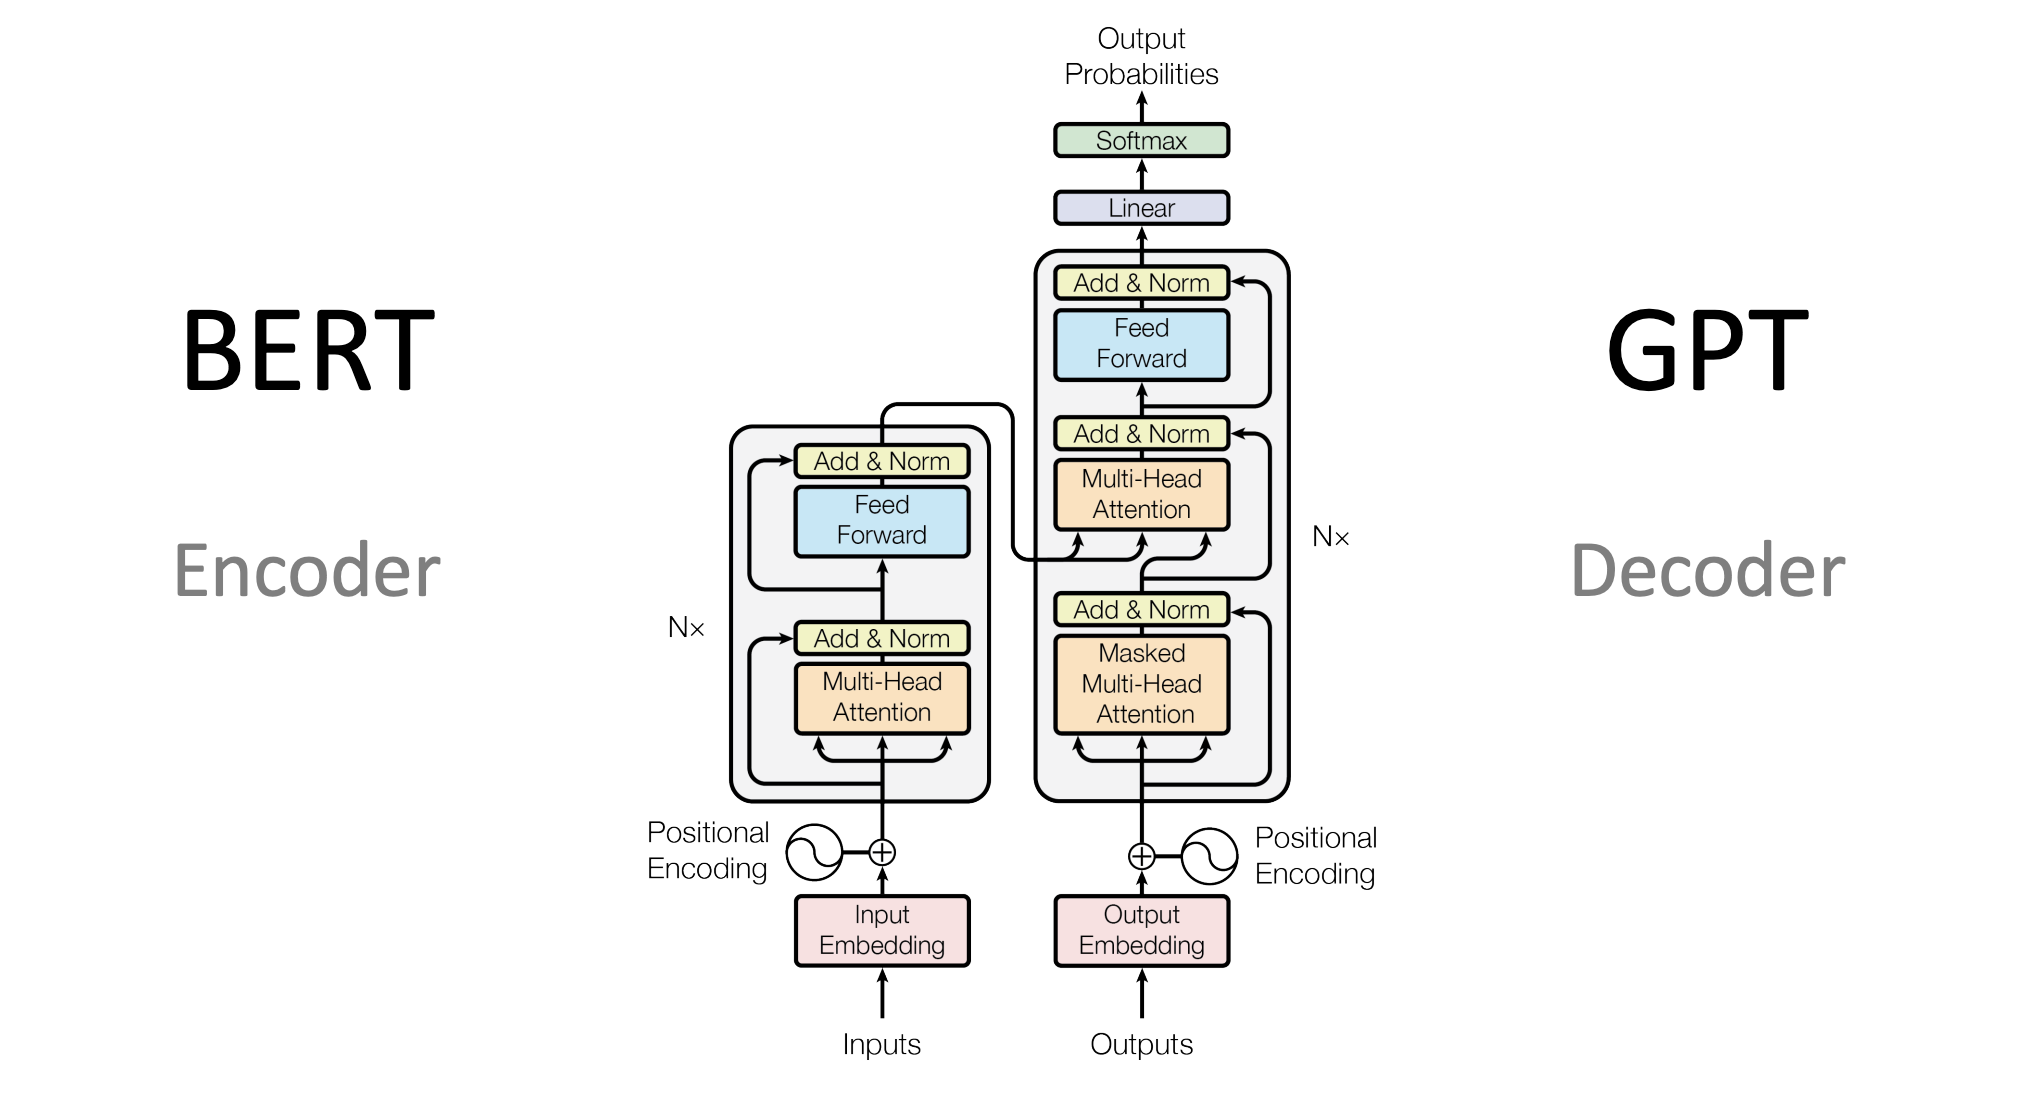

### A Transformer is a neural network architecture that processes all parts of an input sequence simultaneously (in parallel) to understand context and relationships, using a mechanism called self-attention.


### Think of it as reading an entire page at a glance and instantly understanding how every word relates to every other word, rather than reading word-by-word in sequence.




## Simple Analogy: Conference Room Translation


### Imagine translating a meeting in real-time:

- Old RNN way: A single translator listens to each word, forgets parts, and slowly builds a sentence.
- Transformer way: A team of specialists instantly sees the entire sentence. One finds the subject, another finds verbs, another checks adjectives, and they all vote on how each word influences the others to produce a perfect, context-aware translation all at once.

## Core Architecture: The Encoder-Decoder

### The standard Transformer has two main stacks:


## 1. Encoder (Understands the Input)

- Processes the input sequence (e.g., an English sentence)
- Its job is to build a rich, contextual understanding of every word

## 2. Decoder (Generates the Output)

- Uses the encoder's understanding to generate the output sequence (e.g., a French translation)

- Predicts one word at a time, using what it has generated so far

> **Note: Models like BERT are encoder-only (great for understanding), while GPT is decoder-only (great for generation).**

## Transformer Architecture

### The transformer architecture can be broken down into five key components:

1. Tokenization

2. Embedding

3. Positional Encoding

4. Transformer Blocks (a series of them)

5. Softmax Activation Function Layer



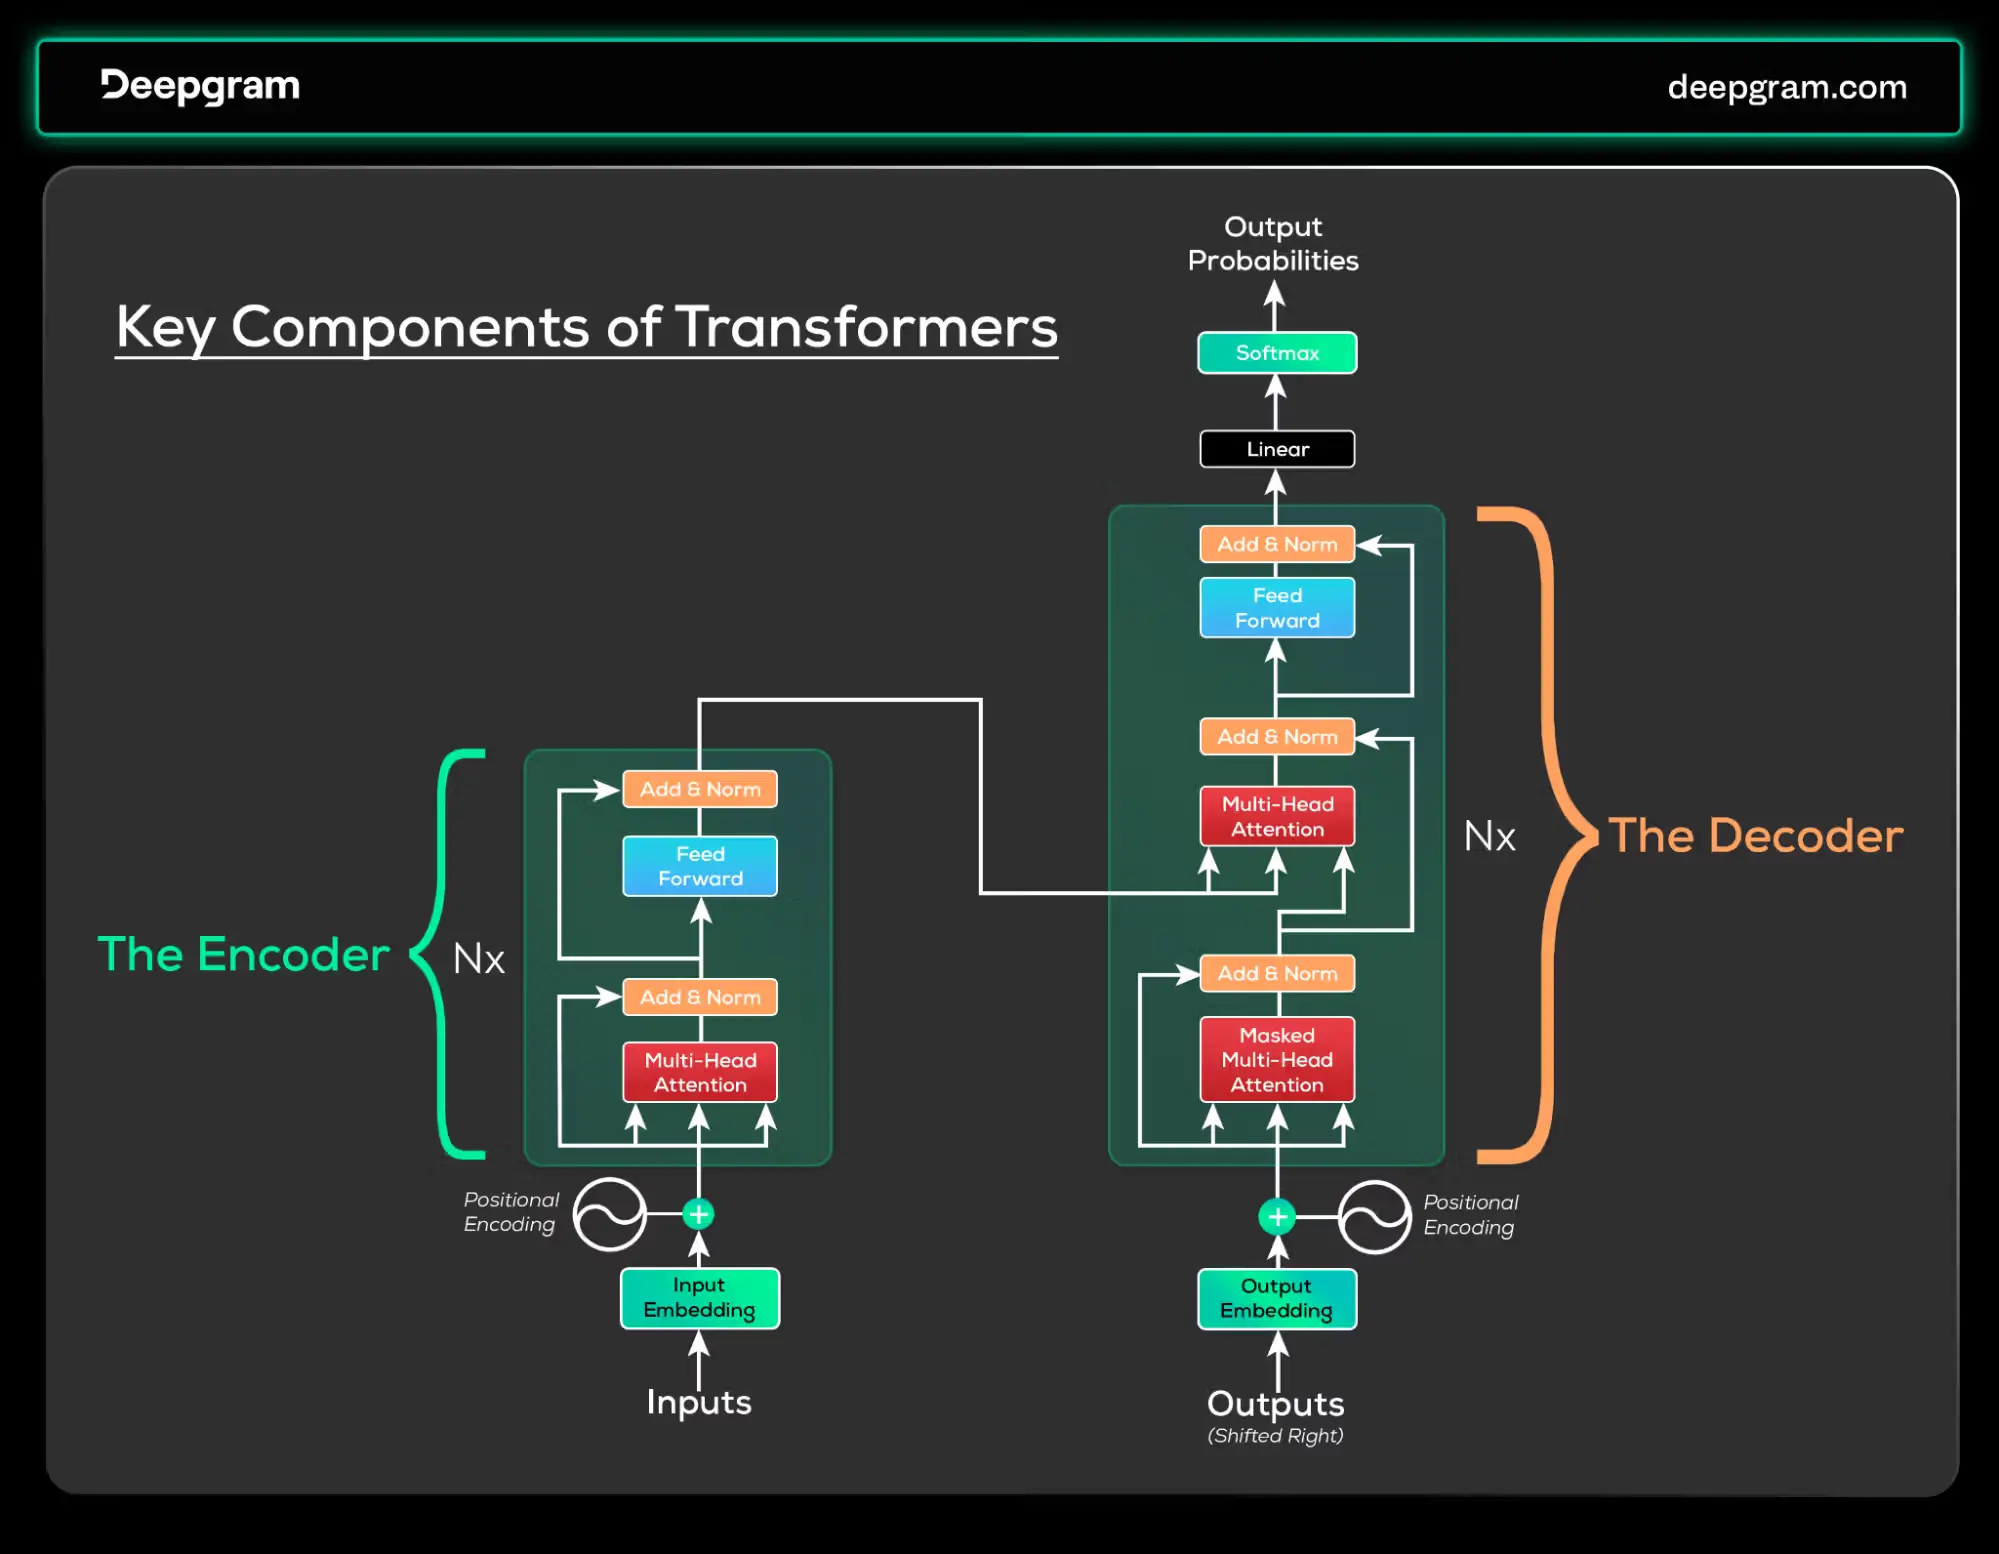

## Tokenization


### Tokenization is a preprocessing technique used to transform human-readable text into a format that computers can process. It involves breaking down text into smaller units, such as sentences or words, making the data easier for models to analyze and process.

Tokenization can be applied at different levels:

- Sentence Tokenization: Splitting a paragraph or corpus into individual sentences.

- Word Tokenization: Further breaking down each sentence into individual words.

For example, consider the following paragraph (corpus):

"The era of smartphones has revolutionized how we generate ideas. Writing is now assisted by intelligent tools that help complete our sentences."



- Sentence Tokenization would split this into:

  1. "The era of smartphones has revolutionized how we generate ideas."

  2. "Writing is now assisted by intelligent tools that help complete our sentences."

- Word Tokenization would break the first sentence into:

    - "The", "era", "of", "smartphones", "has", "revolutionized", "how", "we", "generate", "ideas."

> **This structured representation of text is crucial for feeding data into the transformer model.**

In [1]:
corpus = """
    Hello my name is Ridwan Ibidunni. I am a graduate of mathematics with a keen interest in developing AI applications
    to solve problems in our environments. I love coding and teaching people how to code.
"""

### To tokenize this group of sentences, we have to use the nltk library in python, see the implementation

In [3]:
import nltk # import nltk
# Download the 'punkt_tab' data package
nltk.download('punkt_tab')

#import then method needed to tokenize sentence from nltk
from nltk import sent_tokenize
#apply this method on the corpus
document = sent_tokenize(corpus)

#view the tokenized sentence
for item in document:
    print(item)

""" ### output ###
Hello my name is Ridwan Ibidunni.
I am a graduate of mathematics with a keen interest in developing AI applications
    to solve problems in our environments.
I love coding and teaching people how to code.
"""


    Hello my name is Ridwan Ibidunni.
I am a graduate of mathematics with a keen interest in developing AI applications
    to solve problems in our environments.
I love coding and teaching people how to code.


[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/aljebra/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


' ### output ###\nHello my name is Ridwan Ibidunni.\nI am a graduate of mathematics with a keen interest in developing AI applications\n    to solve problems in our environments.\nI love coding and teaching people how to code.\n'

## This implements sentence tokenization

### Now let’s implement word tokenization for each sentence.

<!-- 

```
What to forget = σ(Weights_f · [Previous Hidden State, Current Input] + Bias_f)

New Cell State = Old Cell State × What to forget
``` -->



In [4]:
#import word tokenization library from nltk
from nltk import word_tokenize

#convert paragraph to word by splitting each into separate word
corpus_tokenized_word = word_tokenize(corpus)

corpus_tokenized_word

""" visualize some of the output
['Hello',
 'my',
 'name',
 'is',
 'Ridwan',
 'Ibidunni',
 '.',
 'I',
 'am',
 'a',
 'graduate',
 'of',
.....
]

"""


" visualize some of the output\n['Hello',\n 'my',\n 'name',\n 'is',\n 'Ridwan',\n 'Ibidunni',\n '.',\n 'I',\n 'am',\n 'a',\n 'graduate',\n 'of',\n.....\n]\n\n"

> **This process breaks down each sentence into individual words. It is the first step performed by a Transformer model when you provide it with a block of text or ask it a question like "write me a story." By tokenizing, the model ensures it can process the input effectively for further stages.**

## Embedding

### After tokenization, the next step in the Transformer model is the Embedding layer. This layer translates human language (e.g., English or any other spoken language) into a numerical format that a computer can process.

### Embedding transforms tokenized words into numerical representations in a vector space. There are different methods to achieve this, including:

## 1. Word Embedding

### Word embeddings act as a bridge between human language and machine understanding. They transform words and text into numerical representations, allowing computers to process and interpret language. Each word is encoded as a unique vector of numbers, capturing its meaning in a form that machines can work with.

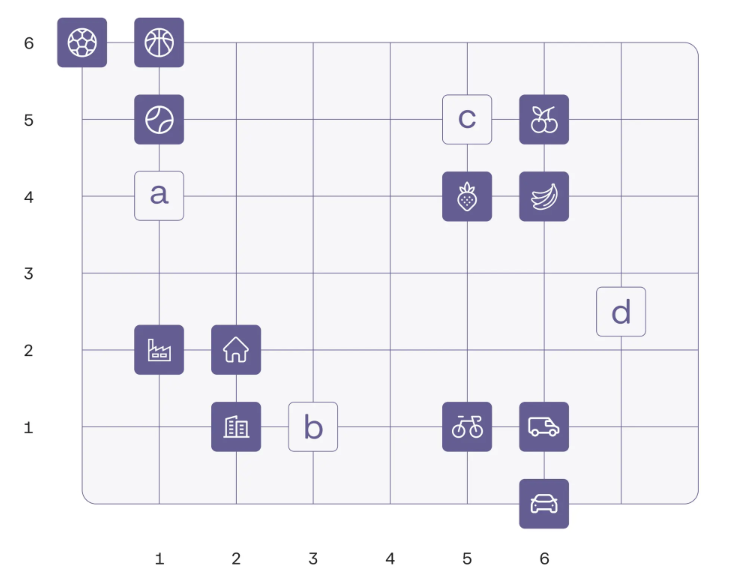

The image above displays the positions of various items, such as bananas, basketballs, houses, buses, and cars, on a two-dimensional grid. The x-axis runs horizontally, while the y-axis runs vertically. Items with similar characteristics are clustered closely together.

Suppose we want to add a new item, like a carrot, to the grid at one of the possible positions marked (a, b, c, d). Which position would be the most suitable?

Word embeddings work similarly by mapping items (or words) onto a plane based on their similarities. In the image, vehicles are positioned in the lower right corner, while sports-related items are in the upper left. This clustering highlights a key principle of embeddings — items (or words) with similar meanings tend to appear near each other.

Since a carrot is a type of fruit/vegetable, it is most likely to be placed near other fruits. The best position for the carrot is “C” at coordinate [5, 5], where other fruits are located.

Beyond grouping similar words, word embeddings capture the unique features and relationships between words. Just as numbers relate to one another through mathematical operations like addition and subtraction, word embeddings can represent and reflect relationships between words in a language, revealing deeper patterns and connections.

## 2. Sentence Embedding

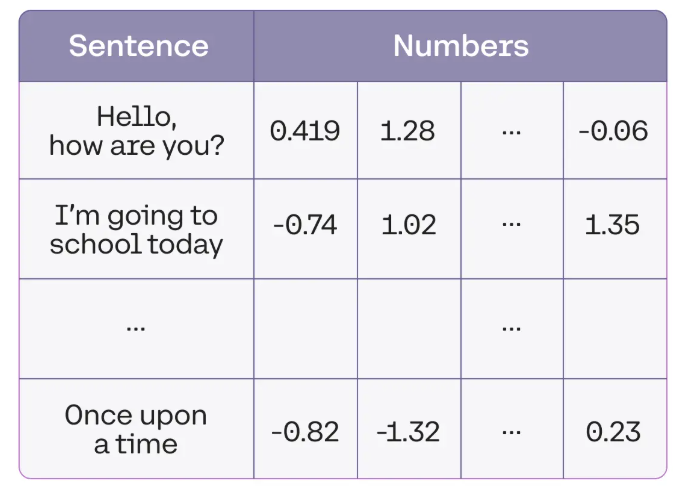

### While word embeddings translate individual words into numerical representations, they fall short when it comes to capturing the meaning of an entire sentence. Simply adding the vectors of each word in a phrase like "No, I am good" doesn’t preserve the full context.

## Example:

### Suppose the following word embeddings are given:

- No: [1, 0, 0, 0]

- I: [0, 2, 0, 0]

- Am: [-1, 0, 1, 0]

- Good: [0, 0, 1, 3]



If we add these vectors to obtain a sentence representation, the result is:
[0, 2, 2, 3]

### Now, consider another sentence: "I am no good." Even though the words are rearranged, their embeddings remain the same. Adding them also results in: [0, 2, 2, 3]

> **This demonstrates a major limitation — simply summing word embeddings gives identical results for sentences with different meanings. AI may mistakenly interpret "No, I am good" and "I am no good" as having the same sentiment, which could lead to incorrect analysis.**

To accurately represent the meaning of a sentence, we need more than just the sum of individual word embeddings. Sentence embeddings take into account the structure and context of the entire phrase, preserving the unique meaning that emerges from the arrangement of words.

## Positional Encoding

### When tokenized words are converted into numerical vectors, they need to be combined back together for the computer to process them effectively. One way to combine vectors is by adding them component-wise. For example, if vector_1 = [2, 3] and vector_2 = [4, 5], their sum would be [6, 8]. However, this approach assumes vector addition is commutative—meaning the order of addition doesn’t matter.



### In language, though, word order is crucial. Sentences like “I’m not sad, I’m happy” and “I’m not happy, I’m sad” contain the same words, but their meaning changes entirely based on the order. Without a mechanism to preserve word order, these sentences would produce identical vectors, which is incorrect.

### Positional encoding solves this problem by encoding the position of each word in a sentence into its corresponding vector. This ensures that sentences with the same words but in a different order produce distinct representations, preserving the unique meaning of each sequence.

## Transformer Block

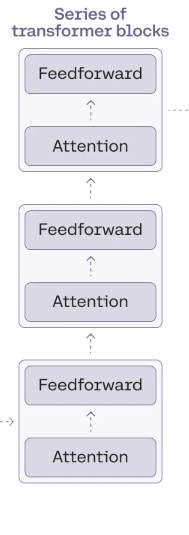

### The Transformer block is the core component responsible for predicting the next word in a sequence, based on the input it receives from the positional encoding layer.

### Each Transformer block consists of two main components:

1. Feedforward Layer: Predicts the next word in the sequence.

2. Attention Layer: Maintains the context of the sentence by analyzing relationships between words.

### These two components work together to form the Transformer block, enabling the model to process language with both accuracy and contextual understanding. As shown in the diagram, the Attention layer is applied at every stage of the feedforward layer, ensuring that word predictions are contextually informed.

## Softmax Activation Layer

### The final layer in the Transformer architecture is the Softmax activation layer. Predictions from the Transformer block (comprising the Attention and Feedforward components) are passed through this layer.



### The Softmax layer converts these predictions into probabilities, producing values between 0 and 1 for each possible next word. The word with the highest probability is selected as the next word in the sequence, enabling the model to generate coherent and contextually appropriate text.